# Fine-tuning LoRA — Stable Diffusion 1.5 sur le dataset Merapi

Ce notebook permet d'entraîner l'adaptateur LoRA sur **Google Colab** avec GPU,
ce qui est **~100× plus rapide** que sur MacBook AIr M1 (MPS).

## Étapes
1. Installer les dépendances
2. Uploader le dataset (ZIP) depuis votre machine
3. Lancer l'entraînement
4. Télécharger le modèle LoRA résultant

In [ ]:
# Vérifier le GPU disponible
!nvidia-smi

Tue Apr 14 17:34:03 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# 1. Installer les dépendances
!pip install -q torch torchvision diffusers transformers accelerate peft pillow pandas

In [ ]:
# 2. Uploader le dataset
# Option A : Upload depuis votre machine
# Créez d'abord le ZIP sur votre Mac :
#   cd merapi_anomaly
#   zip -r merapi_dataset.zip data/processed/ data/index/index.csv

from google.colab import files
import os, zipfile

print("Uploadez merapi_dataset.zip...")
uploaded = files.upload()

# Extraire
with zipfile.ZipFile("merapi_dataset.zip", "r") as z:
    z.extractall("/content/merapi_anomaly/")

print("Dataset extrait dans /content/merapi_anomaly/data/")
!find /content/merapi_anomaly/data/processed -name '*.png' | wc -l

Uploadez merapi_dataset.zip...


Saving merapi_dataset.zip to merapi_dataset.zip
Dataset extrait dans /content/merapi_anomaly/data/
2895


In [ ]:
# Option B : Si le dataset est sur Google Drive
# from google.colab import drive
# drive.mount('/content/drive')
# !cp /content/drive/MyDrive/merapi_dataset.zip .
# !unzip -q merapi_dataset.zip -d /content/merapi_anomaly/

In [ ]:
import os, sys, math, time
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from diffusers import AutoencoderKL, DDPMScheduler, StableDiffusionPipeline, UNet2DConditionModel
from transformers import CLIPTextModel, CLIPTokenizer
from peft import LoraConfig, get_peft_model

device = torch.device("cuda")
dtype = torch.float16  # fp16 sur GPU = 2× plus rapide

print(f"GPU: {torch.cuda.get_device_name()}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

GPU: Tesla T4
VRAM: 15.6 GB


In [ ]:
# ─── Configuration ───────────────────────────────────────────
RESOLUTION = 256
MAX_IMAGES = None       # None = toutes les images
EPOCHS = 50
BATCH_SIZE = 4          # 4 sur T4 (16 Go), 8 sur A100 (40 Go)
LR = 1e-5
GRAD_ACCUM = 4
LORA_RANK = 4
LORA_ALPHA = 4
EMA_DECAY = 0.9999
PATIENCE = 20
SAVE_EVERY = 10
SAMPLE_EVERY = 10

DATA_ROOT = Path("/content/merapi_anomaly/data")
OUTPUT_DIR = Path("/content/lora_merapi_output")
MODEL_ID = "stable-diffusion-v1-5/stable-diffusion-v1-5"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "checkpoints").mkdir(exist_ok=True)
(OUTPUT_DIR / "samples").mkdir(exist_ok=True)

In [ ]:
# ─── Dataset ──────────────────────────────────────────────────

PROMPT_DAY = (
    "volcanic landscape of Mount Merapi, daytime surveillance camera, "
    "gray terrain, lava flow, volcanic texture, smoke plume, "
    "Canon EOS 1100D, scientific observation"
)
PROMPT_NIGHT = (
    "volcanic landscape of Mount Merapi, nighttime surveillance camera, "
    "incandescence, glowing lava, dark terrain, volcanic eruption, "
    "Canon EOS 1100D, scientific observation"
)

class MerapiDataset(Dataset):
    def __init__(self, index_path, processed_base, resolution=256,
                 max_images=None, day_hours=(6, 18)):
        self.resolution = resolution
        df = pd.read_csv(index_path, dtype=str, na_values=["", "None", "nan"])
        df["hour"] = pd.to_numeric(df["hour"], errors="coerce")
        df["year"] = pd.to_numeric(df["year"], errors="coerce")
        df["month"] = pd.to_numeric(df["month"], errors="coerce")
        df = df[df["quality_flag"] == "usable"].copy()

        self.samples = []
        for _, row in df.iterrows():
            y, m, fn = row.get("year"), row.get("month"), row.get("filename", "")
            if pd.isna(y) or pd.isna(m) or not fn:
                continue
            png = processed_base / str(int(y)) / f"{int(m):02d}" / (Path(fn).stem + ".png")
            if not png.exists():
                continue
            hour = row.get("hour")
            is_day = day_hours[0] <= int(hour) < day_hours[1] if pd.notna(hour) else True
            self.samples.append({"path": png, "is_day": is_day})

        if max_images and len(self.samples) > max_images:
            rng = np.random.default_rng(42)
            idx = rng.choice(len(self.samples), max_images, replace=False)
            self.samples = [self.samples[i] for i in sorted(idx)]

        n_day = sum(s["is_day"] for s in self.samples)
        print(f"[Dataset] {len(self.samples)} images ({n_day} jour, {len(self.samples)-n_day} nuit)")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        img = Image.open(s["path"]).convert("L")
        if img.size != (self.resolution, self.resolution):
            img = img.resize((self.resolution, self.resolution), Image.LANCZOS)
        img_rgb = Image.merge("RGB", [img, img, img])
        arr = np.array(img_rgb, dtype=np.float32) / 255.0
        tensor = torch.from_numpy(arr).permute(2, 0, 1) * 2.0 - 1.0
        prompt = PROMPT_DAY if s["is_day"] else PROMPT_NIGHT
        return {"pixel_values": tensor, "prompt": prompt}

dataset = MerapiDataset(
    DATA_ROOT / "index" / "index.csv",
    DATA_ROOT / "processed",
    resolution=RESOLUTION,
    max_images=MAX_IMAGES,
)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True,
                        num_workers=2, pin_memory=True, drop_last=True)

[Dataset] 2671 images (988 jour, 1683 nuit)


In [ ]:
# ─── Charger SD 1.5 + LoRA ───────────────────────────────────
print("Chargement du modèle...")
tokenizer = CLIPTokenizer.from_pretrained(MODEL_ID, subfolder="tokenizer")
text_encoder = CLIPTextModel.from_pretrained(MODEL_ID, subfolder="text_encoder",
                                              torch_dtype=dtype).to(device)
vae = AutoencoderKL.from_pretrained(MODEL_ID, subfolder="vae",
                                     torch_dtype=dtype).to(device)
unet = UNet2DConditionModel.from_pretrained(MODEL_ID, subfolder="unet",
                                             torch_dtype=dtype).to(device)
noise_scheduler = DDPMScheduler.from_pretrained(MODEL_ID, subfolder="scheduler")

vae.requires_grad_(False)
text_encoder.requires_grad_(False)

lora_config = LoraConfig(
    r=LORA_RANK, lora_alpha=LORA_ALPHA,
    init_lora_weights="gaussian",
    target_modules=["to_q", "to_k", "to_v", "to_out.0", "proj_in", "proj_out"],
)
unet = get_peft_model(unet, lora_config)

trainable = sum(p.numel() for p in unet.parameters() if p.requires_grad)
total = sum(p.numel() for p in unet.parameters())
print(f"[LoRA] {trainable:,} / {total:,} paramètres entraînables ({100*trainable/total:.2f}%)")

Chargement du modèle...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/806 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

scheduler_config.json:   0%|          | 0.00/308 [00:00<?, ?B/s]

[LoRA] 996,864 / 860,517,828 paramètres entraînables (0.12%)


In [ ]:
# ─── Helpers ──────────────────────────────────────────────────

def encode_prompt(prompt, tokenizer, text_encoder, device):
    tokens = tokenizer(prompt, padding="max_length",
                       max_length=tokenizer.model_max_length,
                       truncation=True, return_tensors="pt")
    with torch.no_grad():
        return text_encoder(tokens.input_ids.to(device)).last_hidden_state


class EMAModel:
    def __init__(self, parameters, decay=0.9999):
        self.decay = decay
        self.shadow = {i: p.clone().detach() for i, p in enumerate(parameters)}

    @torch.no_grad()
    def update(self, parameters):
        for i, p in enumerate(parameters):
            self.shadow[i].mul_(self.decay).add_(p.data, alpha=1.0 - self.decay)

    def apply_shadow(self, parameters):
        self.backup = {i: p.clone() for i, p in enumerate(parameters)}
        for i, p in enumerate(parameters):
            p.data.copy_(self.shadow[i])

    def restore(self, parameters):
        for i, p in enumerate(parameters):
            p.data.copy_(self.backup[i])

In [ ]:
# ─── Entraînement ────────────────────────────────────────────

params = list(filter(lambda p: p.requires_grad, unet.parameters()))
optimizer = torch.optim.AdamW(params, lr=LR, weight_decay=0.01)
total_steps = EPOCHS * math.ceil(len(dataloader) / GRAD_ACCUM)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_steps, eta_min=LR*0.1)
ema = EMAModel([p for p in unet.parameters() if p.requires_grad], decay=EMA_DECAY)

# Cache des prompts
_pcache = {}
def cached_encode(p):
    if p not in _pcache:
        _pcache[p] = encode_prompt(p, tokenizer, text_encoder, device)
    return _pcache[p]

unet.train()
scaler = torch.cuda.amp.GradScaler()  # Mixed precision
global_step = 0
best_loss = float("inf")
patience_ctr = 0
loss_history = []

print(f"\n{'='*60}")
print(f"ENTRAÎNEMENT LoRA — {EPOCHS} epochs, {len(dataloader)} batches/epoch")
print(f"{'='*60}")

for epoch in range(1, EPOCHS + 1):
    epoch_loss, nb = 0.0, 0
    t0 = time.time()

    for batch_idx, batch in enumerate(dataloader):
        pv = batch["pixel_values"].to(device, dtype=dtype)
        prompts = batch["prompt"]

        with torch.no_grad():
            latents = vae.encode(pv).latent_dist.sample() * vae.config.scaling_factor

        noise = torch.randn_like(latents)
        bsz = latents.shape[0]
        ts = torch.randint(0, noise_scheduler.config.num_train_timesteps,
                           (bsz,), device=device).long()
        noisy = noise_scheduler.add_noise(latents, noise, ts)

        enc_hs = torch.cat([cached_encode(p) for p in prompts], dim=0)

        with torch.cuda.amp.autocast():
            pred = unet(noisy, ts, encoder_hidden_states=enc_hs).sample
            loss = F.mse_loss(pred.float(), noise.float()) / GRAD_ACCUM

        scaler.scale(loss).backward()

        if (batch_idx + 1) % GRAD_ACCUM == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(params, 1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()
            ema.update(p for p in unet.parameters() if p.requires_grad)
            global_step += 1

        epoch_loss += loss.item() * GRAD_ACCUM
        nb += 1

    avg = epoch_loss / max(nb, 1)
    loss_history.append(avg)
    lr = scheduler.get_last_lr()[0]
    dt = time.time() - t0
    print(f"  Epoch {epoch:03d}/{EPOCHS} | Loss={avg:.6f} | LR={lr:.2e} | "
          f"Step={global_step} | {dt:.0f}s")

    if avg < best_loss:
        best_loss = avg
        patience_ctr = 0
        unet.save_pretrained(str(OUTPUT_DIR / "checkpoints" / "best_lora"))
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"\n[Early Stopping] Pas d'amélioration depuis {PATIENCE} epochs.")
            break

    if epoch % SAVE_EVERY == 0:
        unet.save_pretrained(str(OUTPUT_DIR / "checkpoints" / f"lora_epoch_{epoch:03d}"))

print("\nEntraînement terminé !")


ENTRAÎNEMENT LoRA — 50 epochs, 667 batches/epoch


/tmp/ipykernel_10227/1395917617.py:17: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()  # Mixed precision
/tmp/ipykernel_10227/1395917617.py:46: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


  Epoch 001/50 | Loss=0.133434 | LR=9.99e-06 | Step=166 | 236s
  Epoch 002/50 | Loss=0.123934 | LR=9.96e-06 | Step=332 | 236s
  Epoch 003/50 | Loss=0.113141 | LR=9.92e-06 | Step=498 | 236s
  Epoch 004/50 | Loss=0.123775 | LR=9.86e-06 | Step=664 | 236s
  Epoch 005/50 | Loss=0.122625 | LR=9.78e-06 | Step=830 | 236s
  Epoch 006/50 | Loss=0.120500 | LR=9.69e-06 | Step=996 | 236s
  Epoch 007/50 | Loss=0.122329 | LR=9.58e-06 | Step=1162 | 236s
  Epoch 008/50 | Loss=0.116101 | LR=9.45e-06 | Step=1328 | 236s
  Epoch 009/50 | Loss=0.121939 | LR=9.31e-06 | Step=1494 | 236s
  Epoch 010/50 | Loss=0.122248 | LR=9.15e-06 | Step=1660 | 236s
  Epoch 011/50 | Loss=0.122726 | LR=8.98e-06 | Step=1826 | 236s
  Epoch 012/50 | Loss=0.119900 | LR=8.79e-06 | Step=1992 | 235s
  Epoch 013/50 | Loss=0.113737 | LR=8.60e-06 | Step=2158 | 236s
  Epoch 014/50 | Loss=0.117037 | LR=8.39e-06 | Step=2324 | 235s
  Epoch 015/50 | Loss=0.120473 | LR=8.17e-06 | Step=2490 | 236s
  Epoch 016/50 | Loss=0.120373 | LR=7.93e-06 |

In [ ]:
# ─── Sauvegarde finale ────────────────────────────────────────
ema.apply_shadow(p for p in unet.parameters() if p.requires_grad)
unet.save_pretrained(str(OUTPUT_DIR / "lora_merapi_final"))

pd.DataFrame({"epoch": range(1, len(loss_history)+1), "loss": loss_history}
             ).to_csv(OUTPUT_DIR / "training_loss.csv", index=False)

print(f"Modèle LoRA sauvegardé dans {OUTPUT_DIR / 'lora_merapi_final'}")
print(f"Meilleure loss: {best_loss:.6f}")

Modèle LoRA sauvegardé dans /content/lora_merapi_output/lora_merapi_final
Meilleure loss: 0.110273


  0%|          | 0/30 [00:00<?, ?it/s]

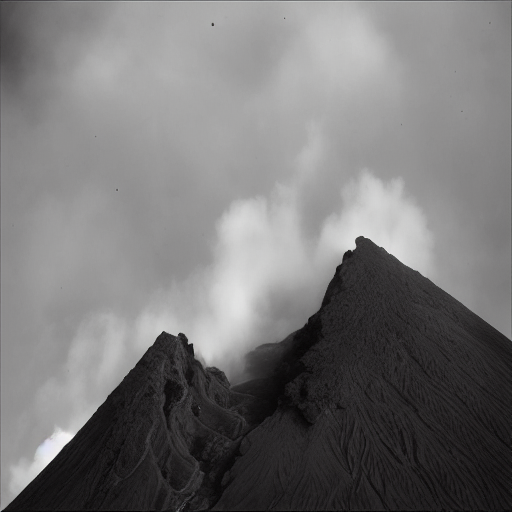

  0%|          | 0/30 [00:00<?, ?it/s]

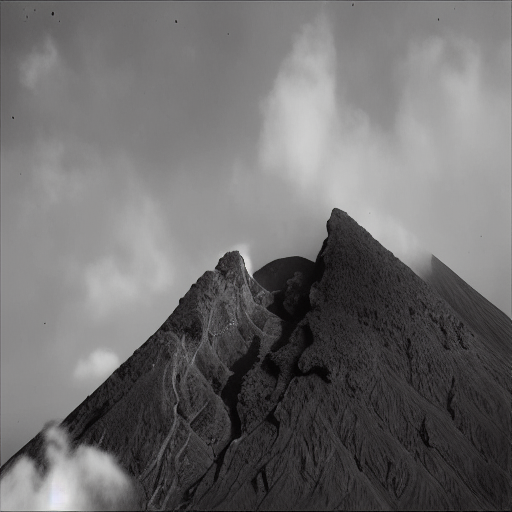

In [ ]:
# ─── Génération d'échantillons ────────────────────────────────
from diffusers import StableDiffusionPipeline

unet.eval()
unet_raw = unet.base_model.model  # unwrap PEFT
pipe = StableDiffusionPipeline(
    vae=vae, text_encoder=text_encoder, tokenizer=tokenizer,
    unet=unet_raw, scheduler=noise_scheduler,
    safety_checker=None, feature_extractor=None,
    requires_safety_checker=False,
).to(device)

gen = torch.Generator(device="cuda").manual_seed(42)
prompts = [PROMPT_DAY, PROMPT_NIGHT]

for i, p in enumerate(prompts):
    img = pipe(p, num_inference_steps=30, generator=gen).images[0]
    img.save(str(OUTPUT_DIR / "samples" / f"final_{i}.png"))
    display(img)

In [ ]:
# ─── Courbe de loss ───────────────────────────────────────────
import matplotlib.pyplot as plt

df = pd.read_csv(OUTPUT_DIR / "training_loss.csv")
plt.figure(figsize=(10, 4))
plt.plot(df["epoch"], df["loss"], "b-")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("LoRA Training Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "training_loss.png"), dpi=150)
plt.show()

In [ ]:
# ─── Télécharger les résultats ────────────────────────────────
import shutil

# Créer un ZIP avec le LoRA final + samples + loss
shutil.make_archive("/content/lora_merapi_results", "zip", str(OUTPUT_DIR))

from google.colab import files
files.download("/content/lora_merapi_results.zip")
print("Téléchargement lancé !")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Téléchargement lancé !
